In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
%matplotlib inline
import matplotlib.pyplot as plt
import sys # sys.path

## CO2 Doubling Experiment - CMIP6 Generation of Models

#### Goal: Recreate values within Nijsse 2019

##### -Succesfully use Gregory two-layer box method to simulate CMIP6 model runs after instaneous CO2 doubling
##### -ECS values are within a small margin of error of Nijsse 2019

In [7]:
t = np.linspace(0, 2000, 2001)
c = 278
f = 1

def firstorder(c, t, f):
    if t > 0:
        f = 2
    else:
        f = 1
    dCdt = f * c
    return dCdt

# Cy, is the Co2 concentration for a given year
Cy = np.zeros_like(t)

for i in range(len(t)):
    Cy[i] = firstorder(c, t[i], f)

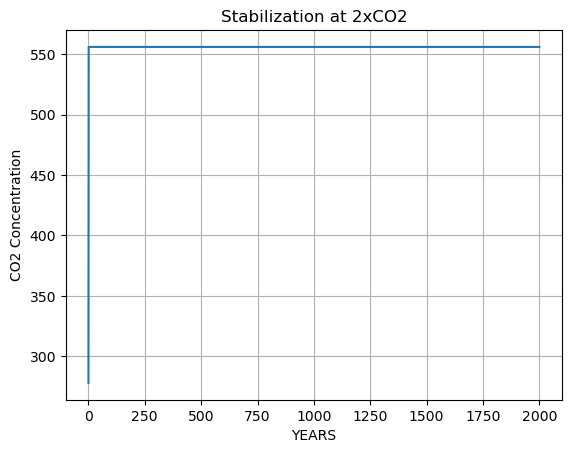

In [9]:
plt.plot(t,Cy)
plt.title('Stabilization at 2xCO2')
plt.xlabel('YEARS')
plt.ylabel('CO2 Concentration')
plt.grid(visible=True)
plt.show()

In [11]:
def co2_ratio(Cy, c0=278.0):
    # Cy, is the estimated co2 concentration for a specific year
    # c0, is the estimated preindustrial level for co2 concentration
    result = Cy / c0 
    return result

ratio = co2_ratio(Cy)

In [15]:
#############################################################################################
# Create a dataframe for parameters in our ode function...
#############################################################################################
df_table = pd.read_csv('Documents/Masters Thesis CSV/Geoffroy_parameters_EBM1_CMIP6.csv')
Model=df_table['Model']
ECS=df_table['ECS']
Gamma=df_table['gamma']
F2=df_table['F_2x']
Lambda=df_table['lambda']
cs=df_table['C']
cd=df_table['C0']
# Create Dataframe
df_constants=pd.DataFrame({'Model':Model,'F2':F2,'Gamma':Gamma, 'Lambda':Lambda, 'ECS':ECS, 'CS':cs, 'CD':cd})
df_constants

,Model,F2,Gamma,Lambda,ECS,CS,CD
0,AWI-CM-1-1-MR,3.799398,0.545347,1.214672,3.127920,6.337677,51.345968
1,BCC-CSM2-MR,3.110177,0.783176,1.028736,3.023299,7.158683,74.092738
2,BCC-ESM1,3.121884,0.664433,0.935236,3.338070,6.842152,96.146885
3,CAMS-CSM1-0,4.053823,0.637562,1.762390,2.300185,7.785771,52.857393
4,FGOALS-f3-L,4.041020,0.710951,1.348249,2.997235,7.160837,70.966699
5,CanESM5,3.702564,0.552251,0.658738,5.620691,6.642386,75.105838
6,CanESM5,3.609734,0.547579,0.637882,5.658940,6.691216,73.938243
7,CNRM-CM6-1,3.585130,0.575613,0.731894,4.898427,6.203427,111.139782
8,CNRM-ESM2-1,3.031505,0.557225,0.638635,4.746849,6.394923,114.269874
9,ACCESS-CM2,3.338554,0.601441,0.710528,4.698697,6.983397,86.933505


In [17]:
# Constants
F2 = np.array(df_constants.iloc[:,1])
gamma = np.array(df_constants.iloc[:,2])
lamb = np.array(df_constants.iloc[:,3])
ECS = np.array(df_constants.iloc[:,4])
cs = np.array(df_constants.iloc[:,5])
cd = np.array(df_constants.iloc[:,6])

In [19]:
# Coupled ODE function for Energy Balanced Model(EBM)
def secondorder(T,t,gamma,lamb,f,cs,cd,e=1):
    dT0dt = (f-T[0]*(lamb+gamma)+ gamma*T[1]-(e-1))/cs    
    dT1dt = (gamma * (T[0] - T[1] ))/cd # T[0]>>>atmosphere, T[1]>>>deep
    return [dT0dt, dT1dt]

In [21]:
def run(time,forcing,gamma,lamb,cs,cd):
    T_start=np.array([0,0])
    Ts=np.zeros(shape=[len(t),2])
    Ts[0,:] = T_start
    for i in range(len(time)-1):
        ts=[time[i], time[i+1]]
        f=forcing[i] # index:year, rcp scenario
        T=odeint(secondorder,T_start,ts,args=(gamma,lamb,f,cs,cd))
        T_start = T[1,:]
        Ts[i+1,:]=T_start
    return Ts

In [23]:
def log_linear(ratio, force=F2[0], base=2):
    result = force*np.log(ratio)/np.log(base)
    return result
log=log_linear(ratio)

In [25]:
# Years of study, can be adjusted as needed...
yr1, yr2 = 0, 2000
nyrs = 2001
t = np.linspace(yr1, yr2, nyrs)

def log_linear(ratio, force=F2[0], base=2):
    result = force * np.log(ratio) / np.log(base)
    return result

log = log_linear(ratio)
Force = log
Tout = run(t, Force, gamma=gamma[0], lamb=lamb[0], cs=cs[0], cd=cd[0])
Temp_sur = Tout[:, 0]
Temp_deep = Tout[:, 1]
df_out = pd.DataFrame()
df_out['F'] = Force
df_out['TS'] = Temp_sur
df_out['TD'] = Temp_deep
Buttercup = "#1_CMIP6_test.csv"
print(Buttercup)
df_out.to_csv(Buttercup)

#1_CMIP6_test.csv


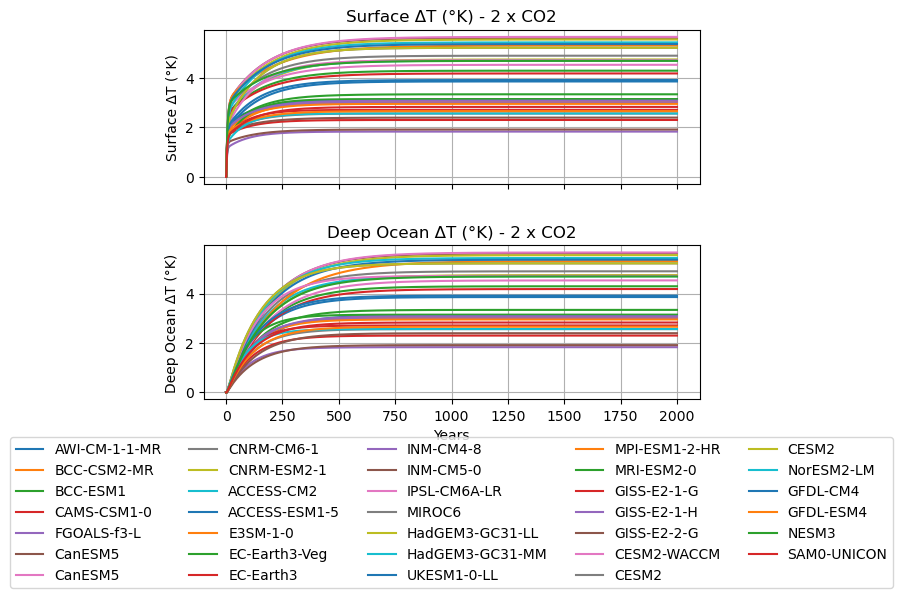

In [27]:
# Create the figure and subplots for the two plots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# List of available models (assumes there are 39 models)
available_models = range(39)

# Plot 1: Surface Temperature - All Models
for model_idx in available_models:
    if model_idx in [17, 24, 25, 32, 38]:
        # Skip missing models
        continue

    # Get the parameters for the current model index
    force = F2[model_idx]
    current_gamma = gamma[model_idx]
    current_lamb = lamb[model_idx]

    log_force = log_linear(ratio, force=force)
    Tout = run(t, log_force, gamma=current_gamma, lamb=current_lamb, cs=cs[0], cd=cd[0])
    Temp_sur = Tout[:, 0]

    # Plot with the model name as the label
    ax1.plot(t, Temp_sur, label=f"{Model[model_idx]}")

# Customize Plot 1
ax1.set_ylabel('Surface ΔT (°K)')
ax1.set_title('Surface ΔT (°K) - 2 x CO2')
ax1.grid(True)

# Plot 2: Deep Ocean Temperatures - All Models
for model_idx in available_models:
    if model_idx in [17, 24, 25, 32, 38]:
        # Skip missing models
        continue

    # Get the parameters for the current model index
    force = F2[model_idx]  # Adjust if deep forcing uses a different parameter (e.g., F4)
    current_gamma = gamma[model_idx]
    current_lamb = lamb[model_idx]

    log_force = log_linear(ratio, force=force)
    Tout = run(t, log_force, gamma=current_gamma, lamb=current_lamb, cs=cs[0], cd=cd[0])
    Temp_deep = Tout[:, 1]

    # Plot with the model name as the label
    ax2.plot(t, Temp_deep, label=f"{Model[model_idx]}")

# Customize Plot 2
ax2.set_xlabel('Years')
ax2.set_ylabel('Deep Ocean ΔT (°K)')
ax2.set_title('Deep Ocean ΔT (°K) - 2 x CO2')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5)
ax2.grid(True)

# Adjust the spacing between the subplots
plt.subplots_adjust(hspace=0.4)
plt.savefig('2_x_co2_CMIP6.png', bbox_inches='tight')
plt.show()

In [31]:
# --------------------------------------------------------
# 1) Define your time array
# --------------------------------------------------------
yr1, yr2 = 0, 2000
nyrs = 2001
t = np.linspace(yr1, yr2, nyrs)

# --------------------------------------------------------
# 2) Prepare empty DataFrames for surface & deep temps
# --------------------------------------------------------
df_ts = pd.DataFrame({'Time': t})
df_td = pd.DataFrame({'Time': t})

# --------------------------------------------------------
# 3) List (or range) of models, skipping missing ones
# --------------------------------------------------------
valid_models = [m for m in range(39) if m not in [17, 24, 25, 32, 38]]

# --------------------------------------------------------
# 4) Loop over each valid model
# --------------------------------------------------------
for model_idx in valid_models:
    # Retrieve the model name from your df_constants
    model_name = df_constants['Model'].iloc[model_idx]

    # Retrieve parameters for this model
    force_4x = F2[model_idx]
    current_gamma = gamma[model_idx]
    current_lamb  = lamb[model_idx]
    current_cs    = cs[model_idx]   # or cs[0], if you intend to reuse the first
    current_cd    = cd[model_idx]   # or cd[0], likewise

    # Compute forcing across time
    # ratio could be an array of length len(t), or a single value if it's constant
    forcing_time_series = log_linear(ratio, force=force_4x)

    # Solve the ODE for this model
    Tout = run(t, forcing_time_series, 
               gamma=current_gamma, lamb=current_lamb, 
               cs=current_cs, cd=current_cd)

    # Extract surface & deep temperatures
    Temp_sur = Tout[:, 0]
    Temp_deep = Tout[:, 1]

    # Use the Model name as column header
    df_ts[model_name] = Temp_sur
    df_td[model_name] = Temp_deep

# --------------------------------------------------------
# 5) Save each DataFrame to a CSV
# --------------------------------------------------------
df_ts.to_csv("TS_CMIP6_2x.csv", index=False)
df_td.to_csv("TD_CMIP6_2x.csv", index=False)

print("Saved two CSV files:")
print(" - TS_CMIP6.csv")
print(" - TD_CMIP6.csv")

Saved two CSV files:
 - TS_CMIP6.csv
 - TD_CMIP6.csv


In [33]:
# 1) Read the CSV of surface temps
df = pd.read_csv("TS_CMIP6_2x.csv")

# 2) Grab the last row (highest Time) as a Series
last_row = df.iloc[-1]

# 3) Remove the "Time" from that Series
last_row = last_row.drop(labels='Time')

# 4) Convert to a DataFrame with a column named "ECS"
ecs_df = last_row.to_frame(name='ECS')

# 5) Turn the index into a "Model" column
ecs_df['Model'] = ecs_df.index
ecs_df = ecs_df[['Model', 'ECS']]  # reorder columns
ecs_df.reset_index(drop=True, inplace=True)

# 6) Save or inspect
ecs_df.to_csv("ECS_last_row_2x.csv", index=False)
print(ecs_df)

              Model       ECS
0     AWI-CM-1-1-MR  3.127919
1       BCC-CSM2-MR  3.023289
2          BCC-ESM1  3.337577
3       CAMS-CSM1-0  2.300185
4       FGOALS-f3-L  2.997232
5           CanESM5  5.657833
6        CNRM-CM6-1  4.891246
7       CNRM-ESM2-1  4.733559
8        ACCESS-CM2  4.697275
9     ACCESS-ESM1-5  3.856736
10         E3SM-1-0  5.312092
11    EC-Earth3-Veg  4.292679
12        EC-Earth3  4.180811
13        INM-CM4-8  1.830486
14        INM-CM5-0  1.914223
15     IPSL-CM6A-LR  4.530386
16           MIROC6  2.556997
17  HadGEM3-GC31-LL  5.550614
18  HadGEM3-GC31-MM  5.436280
19      UKESM1-0-LL  5.367742
20    MPI-ESM1-2-HR  2.951453
21       MRI-ESM2-0  3.146094
22      GISS-E2-1-G  2.708497
23      GISS-E2-1-H  3.081071
24      GISS-E2-2-G  2.145121
25      CESM2-WACCM  4.713231
26            CESM2  5.218998
27       NorESM2-LM  2.563427
28         GFDL-CM4  3.914397
29        GFDL-ESM4  2.656077
30            NESM3  4.685261
31      SAM0-UNICON  2.828305


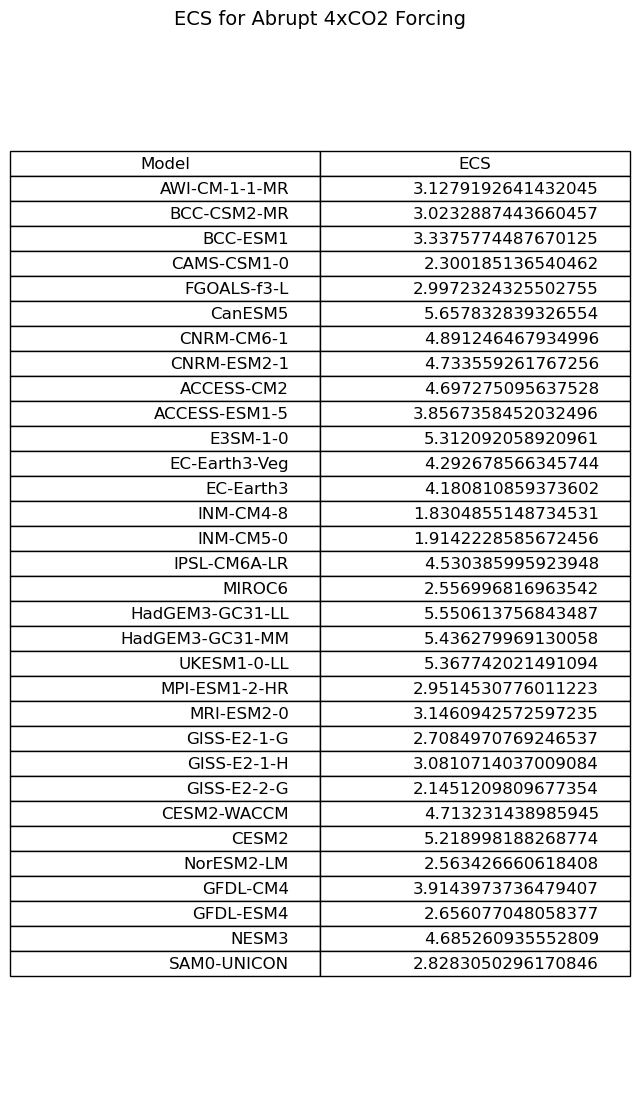

In [35]:
# Plot the table using matplotlib
fig, ax = plt.subplots(figsize=(8, len(ecs_df)*0.4 + 1))
ax.axis('off')
table = ax.table(cellText=ecs_df.values, colLabels=ecs_df.columns, loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)
plt.title('ECS for Abrupt 4xCO2 Forcing', fontsize=14)
plt.savefig('Table_2xco2_2layer.png')
plt.show()